# Линейная регрессия. Практическая работа 2

## Цель практической работы

Научиться строить модель линейной регрессии на реальных данных.

## Что входит в практическую работу

1. Загрузить данные и ознакомиться с ними.
2. Изучить данные и провести анализ.
3. Закодировать категориальные признаки.
4. Разделить данные на обучающую и тестовую выборки.
5. Реализовать построение модели с помощью библиотеки scikit-learn.
6. Получить качество модели с помощью MSE, MAE.
7. Сделать вывод о качестве модели и о том, переобучилась ли она.

## Что оценивается

* Выполнены все этапы работы.
* Категориальные признаки закодированы корректно (без утечки данных между train и test).
* Сделан вывод по результатам.
* Модель не переобучена.
* Получена модель хорошего качества.

## Что нужно сделать

Дан набор данных `cars.csv` о продаже автомобилей с пробегом:

- **price** (цена продажи, *зависимая переменная*).
- **year** (год выпуска).
- **mileage** (пробег, км).
- **engine_volume** (объём двигателя, л).
- **horsepower** (мощность, л.с.).
- **fuel_type** (тип топлива: Petrol / Diesel / Hybrid / Electric).
- **transmission** (тип трансмиссии: Manual / Automatic).
- **brand** (марка автомобиля).

Реализуйте построение модели линейной регрессии на этих данных. Проверьте качество модели на обучающей и тестовой выборках с помощью MAE, MSE. Определите, не переобучилась ли модель.

### 1. Импорт библиотек

Импортируйте все библиотеки, которые понадобятся для работы: pandas, numpy, matplotlib/seaborn, а также нужные классы и функции из sklearn (`LinearRegression`, `train_test_split`, `OneHotEncoder`, `mean_squared_error`, `mean_absolute_error`).

In [22]:
# Ваш код здесь
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 2. Загрузка данных

Загрузите файл `cars.csv` в датафрейм и посмотрите на первые строки.

In [5]:
# Ваш код здесь
df = pd.read_csv('cars.csv')
df.head()

,price,year,mileage,engine_volume,horsepower,fuel_type,transmission,brand
0,14900,2006,154947,1.8,129,Petrol,Automatic,BMW
1,30900,2019,50767,3.0,197,Petrol,Manual,Volkswagen
2,21840,2017,48093,1.6,88,Petrol,Manual,Toyota
3,18350,2013,77397,1.6,102,Petrol,Automatic,Toyota
4,16010,2013,143391,2.0,113,Petrol,Manual,Toyota


### 3. Первичный анализ

1. Проверьте данные на пропуски.
2. Посмотрите на распределения числовых признаков и на зависимость цены от каждого из них (например, с помощью `sns.pairplot` или отдельных `scatter`-графиков).
3. Посмотрите на распределение категориальных признаков (`value_counts()`) — обратите внимание, есть ли сильный дисбаланс классов, и подумайте, как это может повлиять на модель.
4. Закодируйте категориальные признаки (`fuel_type`, `transmission`, `brand`) с помощью `OneHotEncoder` или `pd.get_dummies`.
5. Подумайте, можно ли создать дополнительные признаки из имеющихся (например, «возраст автомобиля» на основе года выпуска).
6. Сделайте предварительные выводы.

In [6]:
# Ваш код здесь
df.isnull().sum()

price            0
year             0
mileage          0
engine_volume    0
horsepower       0
fuel_type        0
transmission     0
brand            0
dtype: int64

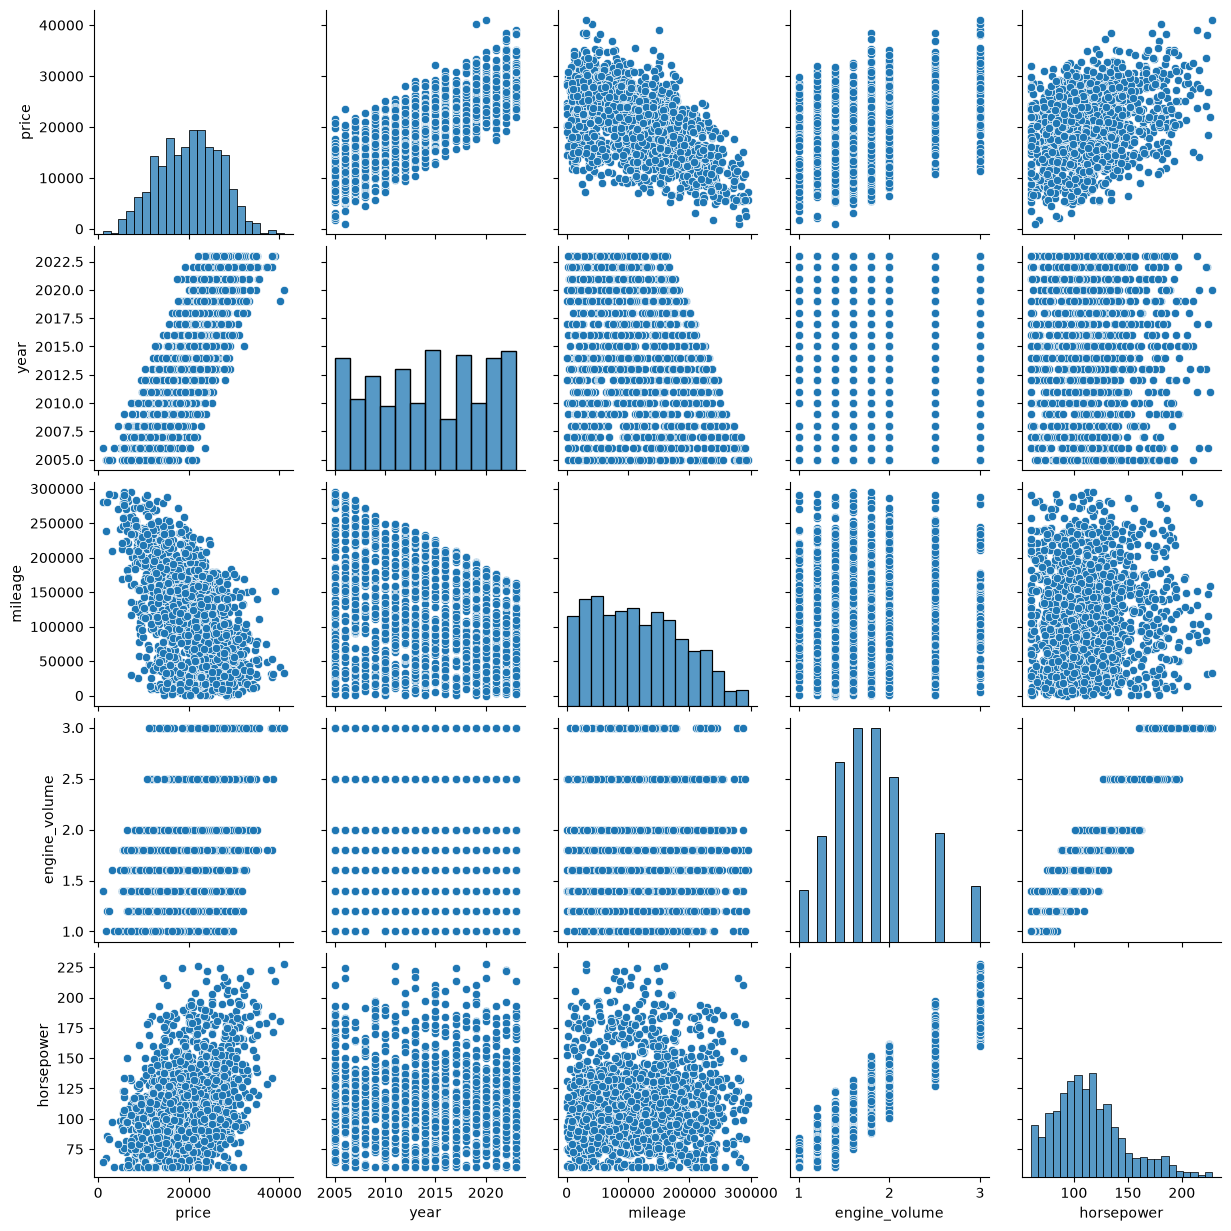

In [7]:
sns.pairplot(df)

In [10]:
cat_features = ['fuel_type', 'transmission', 'brand']

for f in cat_features:
    print('-'*50)
    print(f)
    print(df[f].value_counts())

--------------------------------------------------
fuel_type
fuel_type
Petrol      839
Diesel      385
Hybrid      171
Electric    105
Name: count, dtype: int64
--------------------------------------------------
transmission
transmission
Automatic    909
Manual       591
Name: count, dtype: int64
--------------------------------------------------
brand
brand
Toyota        395
Kia           326
Renault       283
Volkswagen    272
BMW           224
Name: count, dtype: int64


все переменные сбалансированы

### 4. Разделение на обучающую и тестовую выборки

Разделите данные на признаки (X) и целевую переменную (y), а затем на обучающую и тестовую выборки с помощью `train_test_split`.

**Важно:** если вы кодируете категориальные признаки с помощью `OneHotEncoder` из sklearn, кодировщик нужно обучать (`fit`) только на обучающей выборке, а к тестовой применять только `transform` — иначе возможна утечка данных.

In [14]:
# Ваш код здесь
X = df.drop(columns=['price'])
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42)

cat_cols = x_train.select_dtypes(include='object').columns.tolist()

encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

x_train_encoded = encoder.fit_transform(x_train[cat_cols])
x_test_encoded = encoder.transform(x_test[cat_cols])

x_train_encoded_df = pd.DataFrame(x_train_encoded, columns=encoder.get_feature_names_out(cat_cols), index=x_train.index)
x_test_encoded_df = pd.DataFrame(x_test_encoded, columns=encoder.get_feature_names_out(cat_cols), index=x_test.index)

x_train = pd.concat([x_train.drop(columns=cat_cols), x_train_encoded_df], axis=1)
x_test = pd.concat([x_test.drop(columns=cat_cols), x_test_encoded_df], axis=1)

C:\Users\Arsenii\AppData\Local\Temp\ipykernel_14836\4265476085.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x_train.select_dtypes(include='object').columns.tolist()


### 5. Обучение модели линейной регрессии

Обучите модель `LinearRegression` на обучающей выборке. Дополнительно можно взглянуть на коэффициенты и смещение обученной модели.

In [18]:
# Ваш код здесь
lr = LinearRegression()
lr.fit(x_train, y_train)
print(lr.coef_)
print()
print(lr.intercept_)

[ 9.02585231e+02 -3.02723815e-02  2.48195779e+03  3.95238986e+01
  2.80343580e+03  1.58573770e+03 -1.51059298e+03 -1.26143951e+03
 -4.21288194e+03 -4.51529107e+03 -3.54899100e+03 -3.83782648e+03]

-1798839.1582343506


In [24]:
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 902.59, -0.03, 2481.96,...,-4515.29,-3548.99,-3837.83]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['year','mileage','engine_volume',...,'brand_Renault','brand_Toyota', 'brand_Volkswagen']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.799e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


### 6. Получение предсказаний для обучающей и тестовой выборок

In [20]:
# Ваш код здесь
y_train_pred = lr.predict(x_train)
y_test_pred = lr.predict(x_test)

### 7. Проверка предсказаний

1. Посчитайте MAE и MSE на обучающей и тестовой выборках.
2. Постройте диаграмму рассеяния целевой и предсказанной переменных (`y_test` против `y_test_pred`).
3. Сравните ошибки на train и test — сделайте вывод, не переобучилась ли модель.
4. Оцените, насколько велика ошибка относительно среднего значения цены — хорошее ли это качество модели?

In [23]:
# Ваш код здесь
print(f'train MAE: {mean_absolute_error(y_train, y_train_pred)}')
print(f'test MAE: {mean_absolute_error(y_test, y_test_pred)}')
print('-' * 25)
print(f'train MSE: {mean_squared_error(y_train, y_train_pred)}')
print(f'test MSE: {mean_squared_error(y_test, y_test_pred)}')

train MAE: 633.4744019108531
test MAE: 680.4076034124847
-------------------------
train MSE: 616437.1671133637
test MSE: 711896.9983155


### 8. Вывод

Напишите здесь текстовый вывод по результатам работы: какое качество получилось у модели, переобучена ли она, какие признаки, на ваш взгляд, оказались наиболее важными, и что можно было бы попробовать улучшить.

модель переобучена (overfitting) и в данных, скорее всего, присутствуют крупные выбросы.